# Cross-Venue Arbitrage in Fragmented Markets — Spanish Equities (BME + MTFs)
### *Arbitrage study in BME* — corrected implementation

**Methodology** (aligned with the lab brief and the in-class correction of 10-Dec-2025):

| Step | What it does |
|------|--------------|
| **1. Ingestion & cleaning** | Load `QTE` + `STS` per ISIN across venues; drop vendor *magic numbers* / invalid prices. |
| **2. Market status + Consolidated Tape** | Keep only **Continuous Trading** snapshots (`merge_asof` by `epoch` **and** `mic`); pivot best bid/ask by venue and **forward-fill** latent prices. |
| **3. Signal generation** | `Global Max Bid > Global Min Ask`; profit `= (MaxBid − MinAsk) × min(BidQty, AskQty)`; **rising-edge** rule so each opportunity is counted once. |
| **4. The Time Machine** | For each latency Δ, look up the *actual* profit at `T + Δ` (`merge_asof` on integer µs epoch). Optimistic fill-or-kill: never realise a loss. |

> All timestamps are kept as **integer microsecond `epoch`** throughout, so latency is added in native µs (no datetime unit pitfalls).


## 0. Configuration

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ---- Data location -------------------------------------------------------
# Point BASE to the folder that contains DATA_BIG / DATA_SMALL.
BASE = r"C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\2.Introduccion a los Sistemas Financieros\Tareas\Renta Variable"
USE_SMALL = False          # True -> quick test on DATA_SMALL ; False -> full DATA_BIG
DATA_PATH = os.path.join(BASE, "DATA_SMALL" if USE_SMALL else "DATA_BIG")
MAX_ISINS = None           # e.g. 20 to cap the run; None = all

# ---- Venue / status maps (from the vendor spec) --------------------------
MIC_TO_VENUE = {"XMAD": "BME", "AQEU": "AQUIS", "CEUX": "CBOE", "TQEX": "TURQUOISE"}
CONTINUOUS_STATUS_BY_MIC = {
    "XMAD": {5832713, 5832756},   # BME
    "AQEU": {5308427},            # AQUIS
    "CEUX": {12255233},           # CBOE
    "TQEX": {7608181},            # TURQUOISE
}
MAGIC_THRESHOLD = 100_000.0       # any px above this is a vendor magic number (999999.x / 666666.666)
LATENCIES_US = [0, 100, 500, 1000, 2000, 3000, 4000, 5000,
                10000, 15000, 20000, 30000, 50000, 100000]

QTE_COLS = ["isin", "mic", "epoch", "px_bid_0", "qty_bid_0", "px_ask_0", "qty_ask_0"]
STS_COLS = ["mic", "epoch", "market_trading_status"]
print("Data path:", DATA_PATH, "| exists:", os.path.isdir(DATA_PATH))

Data path: C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\2.Introduccion a los Sistemas Financieros\Tareas\Renta Variable\DATA_BIG | exists: True


## 1. Data Ingestion & Cleaning
Files are `;`-separated and gzip-compressed. `epoch` is a microsecond UTC timestamp.
Prices `>= 100,000` or `<= 0` are **magic numbers / invalid** and are set to `NaN` (never treated as tradable).

In [2]:
def list_isins(data_path):
    """All ISINs present in the QTE filenames (3rd underscore token)."""
    isins = set()
    for f in glob.glob(os.path.join(data_path, "*", "QTE_*.csv.gz")):
        parts = os.path.basename(f).split("_")
        if len(parts) >= 3:
            isins.add(parts[2])
    return sorted(isins)


def _read_many(kind, isin, data_path, cols):
    frames = []
    for f in glob.glob(os.path.join(data_path, "*", f"{kind}_*_{isin}_*.csv.gz")):
        try:
            frames.append(pd.read_csv(f, sep=";", compression="gzip",
                                      usecols=lambda c: c in cols))
        except Exception as e:
            print(f"   ! skip {os.path.basename(f)}: {e}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=cols)


def load_isin(isin, data_path):
    """Return (qte, sts) with numeric epoch (int64 µs) and magic-number-cleaned prices."""
    qte = _read_many("QTE", isin, data_path, QTE_COLS)
    sts = _read_many("STS", isin, data_path, STS_COLS)
    if qte.empty:
        return qte, sts
    for c in ["epoch", "px_bid_0", "qty_bid_0", "px_ask_0", "qty_ask_0"]:
        qte[c] = pd.to_numeric(qte[c], errors="coerce")
    qte = qte.dropna(subset=["epoch"])
    qte["epoch"] = qte["epoch"].astype("int64")
    for c in ["px_bid_0", "px_ask_0"]:                      # magic / invalid -> NaN
        qte.loc[(qte[c] >= MAGIC_THRESHOLD) | (qte[c] <= 0), c] = np.nan
    if not sts.empty:
        sts["epoch"] = pd.to_numeric(sts["epoch"], errors="coerce")
        sts["market_trading_status"] = pd.to_numeric(sts["market_trading_status"], errors="coerce")
        sts = sts.dropna(subset=["epoch"])
        sts["epoch"] = sts["epoch"].astype("int64")
    return qte, sts

print("Step 1 functions ready.")

Step 1 functions ready.


## 2. Market Status Filter + Consolidated Tape
**Status filter** — a snapshot is only *addressable* when its venue is in **Continuous Trading**.
We `merge_asof` each quote onto the latest status *for the same `mic`* (`by="mic"`), then keep the continuous codes.
This is what removes the fake auction/pre-open signals (the 9–10-point criterion).

**Consolidated tape** — pivot the best bid/ask/qty into one column block per venue, **forward-fill** so each
row carries the last known price per venue, then take the global best bid (max) and best ask (min).

In [3]:
def filter_continuous(qte, sts):
    if sts.empty:
        print("   ! no STS -> keeping all snapshots (status filter unavailable)")
        return qte
    q = qte.sort_values("epoch")
    s = sts[["epoch", "mic", "market_trading_status"]].sort_values("epoch")
    merged = pd.merge_asof(q, s, on="epoch", by="mic", direction="backward")
    cont = pd.Series(False, index=merged.index)
    for mic, codes in CONTINUOUS_STATUS_BY_MIC.items():
        cont |= (merged["mic"] == mic) & (merged["market_trading_status"].isin(list(codes)))
    return merged[cont].copy()


def build_tape(qte):
    """Cross-venue best bid/ask/qty, forward-filled, with global best prices and venue attribution."""
    tape = qte.pivot_table(index="epoch", columns="mic",
                           values=["px_bid_0", "px_ask_0", "qty_bid_0", "qty_ask_0"],
                           aggfunc="last").sort_index()     # aggfunc='last' de-dups (epoch, mic)
    tape = tape.ffill()
    mics = sorted({m for _, m in tape.columns})

    def mat(metric):
        cols = [(metric, m) for m in mics if (metric, m) in tape.columns]
        return tape[cols].to_numpy(dtype=float), [m for (_, m) in cols]

    bid_px, bmics = mat("px_bid_0")
    ask_px, amics = mat("px_ask_0")
    bid_q, _ = mat("qty_bid_0")
    ask_q, _ = mat("qty_ask_0")
    n = tape.shape[0]

    has_bid = ~np.all(np.isnan(bid_px), axis=1)
    has_ask = ~np.all(np.isnan(ask_px), axis=1)
    valid = has_bid & has_ask

    max_bid = np.full(n, np.nan); min_ask = np.full(n, np.nan)
    bid_qty = np.full(n, np.nan); ask_qty = np.full(n, np.nan)
    bid_ven = np.array([None] * n, dtype=object)
    ask_ven = np.array([None] * n, dtype=object)
    if valid.any():
        vi = np.where(valid)[0]
        bidi = np.nanargmax(np.where(np.isnan(bid_px), -np.inf, bid_px)[vi], axis=1)
        aski = np.nanargmin(np.where(np.isnan(ask_px), np.inf, ask_px)[vi], axis=1)
        max_bid[vi] = bid_px[vi, bidi]; min_ask[vi] = ask_px[vi, aski]
        bid_qty[vi] = bid_q[vi, bidi];  ask_qty[vi] = ask_q[vi, aski]
        bid_ven[vi] = [MIC_TO_VENUE.get(bmics[i], bmics[i]) for i in bidi]
        ask_ven[vi] = [MIC_TO_VENUE.get(amics[i], amics[i]) for i in aski]

    out = pd.DataFrame(index=tape.index)
    out["max_bid"], out["min_ask"] = max_bid, min_ask
    out["bid_qty"], out["ask_qty"] = bid_qty, ask_qty
    out["bid_venue"], out["ask_venue"] = bid_ven, ask_ven
    return out.dropna(subset=["max_bid", "min_ask"])

print("Step 2 functions ready.")

Step 2 functions ready.


## 3. Signal Generation (with Rising-Edge de-duplication)
An opportunity exists when `Global Max Bid > Global Min Ask`.
Because a crossed book persists across many microsecond snapshots, we count only the **rising edge**
(`is_arb` now **and** not `is_arb` on the previous snapshot) — otherwise the same opportunity is counted thousands of times.

In [4]:
def compute_signals(tape):
    t = tape.copy()
    t["spread"] = t["max_bid"] - t["min_ask"]
    t["tradable_qty"] = np.minimum(t["bid_qty"], t["ask_qty"])
    t["is_arb"] = t["spread"] > 0
    t["profit_potential"] = np.where(t["is_arb"], t["spread"] * t["tradable_qty"], 0.0)
    prev = t["is_arb"].shift(1, fill_value=False)
    t["new_opp"] = t["is_arb"] & (~prev)        # rising edge
    return t

print("Step 3 function ready.")

Step 3 function ready.


## 4. The Time Machine — Latency Simulation
For every detected opportunity at `T`, the order only reaches the market at `T + Δ`.
We look up the realised profit at `T + Δ` with a backward `merge_asof` on integer-µs epoch.
`profit_potential` is `0` whenever the book is not crossed, so a vanished opportunity realises **€0**
(optimistic fill-or-kill: we never book a loss — matching the correction's assumption).

In [5]:
def simulate_latency(tape, latencies=LATENCIES_US):
    opp_epochs = tape.index[tape["new_opp"]].to_numpy()
    pp = tape[["profit_potential"]].reset_index().sort_values("epoch")
    out = {}
    for lat in latencies:
        left = pd.DataFrame({"epoch": np.sort(opp_epochs + lat)})
        m = pd.merge_asof(left, pp, on="epoch", direction="backward")
        out[lat] = float(m["profit_potential"].fillna(0).clip(lower=0).sum())
    return out, int(len(opp_epochs))

print("Step 4 function ready.")

Step 4 function ready.


## 5. Run the full pipeline over all ISINs

In [6]:
def process_isin(isin, data_path):
    qte, sts = load_isin(isin, data_path)
    if qte.empty:
        return None
    q = filter_continuous(qte, sts)
    if q.empty:
        return None
    tape = compute_signals(build_tape(q))
    if tape.empty:
        return None
    res, n_opp = simulate_latency(tape)

    opps = tape[tape["new_opp"]].copy()
    opps["profit"] = opps["profit_potential"]
    opps["spread_bps"] = opps["spread"] / opps["min_ask"] * 1e4
    top = opps.sort_values("profit", ascending=False).head(10).copy()
    top["time_cet"] = (pd.to_datetime(top.index, unit="us", utc=True)
                       .tz_convert("Europe/Madrid"))
    return {"isin": isin, "res": res, "n_opp": n_opp, "rows": len(tape),
            "top": top[["time_cet", "max_bid", "min_ask", "spread_bps",
                        "tradable_qty", "profit", "bid_venue", "ask_venue"]]}


isins = list_isins(DATA_PATH)
if MAX_ISINS:
    isins = isins[:MAX_ISINS]
print(f"Processing {len(isins)} ISIN(s) from {os.path.basename(DATA_PATH)} ...\n")

money, detail = {}, {}
for i, isin in enumerate(isins, 1):
    r = process_isin(isin, DATA_PATH)
    if r is None:
        print(f"[{i}/{len(isins)}] {isin}: no usable data"); continue
    money[isin] = r["res"]; detail[isin] = r
    print(f"[{i}/{len(isins)}] {isin}: rows={r['rows']:>7} new_opps={r['n_opp']:>5} "
          f"profit@0us={r['res'][0]:>11,.2f} EUR  profit@100ms={r['res'][LATENCIES_US[-1]]:>9,.2f}")
print("\nDone.")

Processing 195 ISIN(s) from DATA_BIG ...

[1/195] ARP125991090: no usable data
[2/195] AU000000BKY0: rows=   3106 new_opps=    0 profit@0us=       0.00 EUR  profit@100ms=     0.00
[3/195] BRBBDCACNPR8: no usable data
[4/195] BRPETRACNOR9: no usable data
[5/195] BRPETRACNPR6: no usable data
[6/195] BRUSIMACNOR3: no usable data
[7/195] DE000FA5G8E7: rows=    340 new_opps=    0 profit@0us=       0.00 EUR  profit@100ms=     0.00
[8/195] DE000FA5HCF1: rows=    652 new_opps=    0 profit@0us=       0.00 EUR  profit@100ms=     0.00
[9/195] DE000FA5HGL0: rows=   1497 new_opps=    0 profit@0us=       0.00 EUR  profit@100ms=     0.00
[10/195] DE000FA5HH03: rows=    784 new_opps=    0 profit@0us=       0.00 EUR  profit@100ms=     0.00
[11/195] DE000FA5HJJ8: rows=    407 new_opps=    0 profit@0us=       0.00 EUR  profit@100ms=     0.00
[12/195] DE000FD1Q005: rows=   1387 new_opps=    0 profit@0us=       0.00 EUR  profit@100ms=     0.00
[13/195] DE000FD1Q0E0: rows=   1834 new_opps=    2 profit@0us= 

## 6. Deliverable 1 — The Money Table
Total **realised** profit (EUR) per ISIN at each latency level.

In [7]:
money_table = pd.DataFrame(money).T.reindex(columns=LATENCIES_US)
money_table.index.name = "ISIN"
money_table.loc["TOTAL"] = money_table.sum()
money_table.columns = [f"{c}us" for c in money_table.columns]
display(money_table.style.format("{:,.2f}")
        .background_gradient(cmap="Greens", axis=None)
        .set_caption("Realised arbitrage profit (EUR) by execution latency"))

,0us,100us,500us,1000us,2000us,3000us,4000us,5000us,10000us,15000us,20000us,30000us,50000us,100000us
ISIN,,,,,,,,,,,,,,
AU000000BKY0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
DE000FA5G8E7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
DE000FA5HCF1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
DE000FA5HGL0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
DE000FA5HH03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
DE000FA5HJJ8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
DE000FD1Q005,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
DE000FD1Q0E0,103.48,103.48,103.48,103.48,103.48,103.48,103.48,103.48,103.48,103.48,103.48,103.48,103.48,103.48
DE000FD1Q0S0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## 7. Deliverable 2 — The Latency-Decay Chart

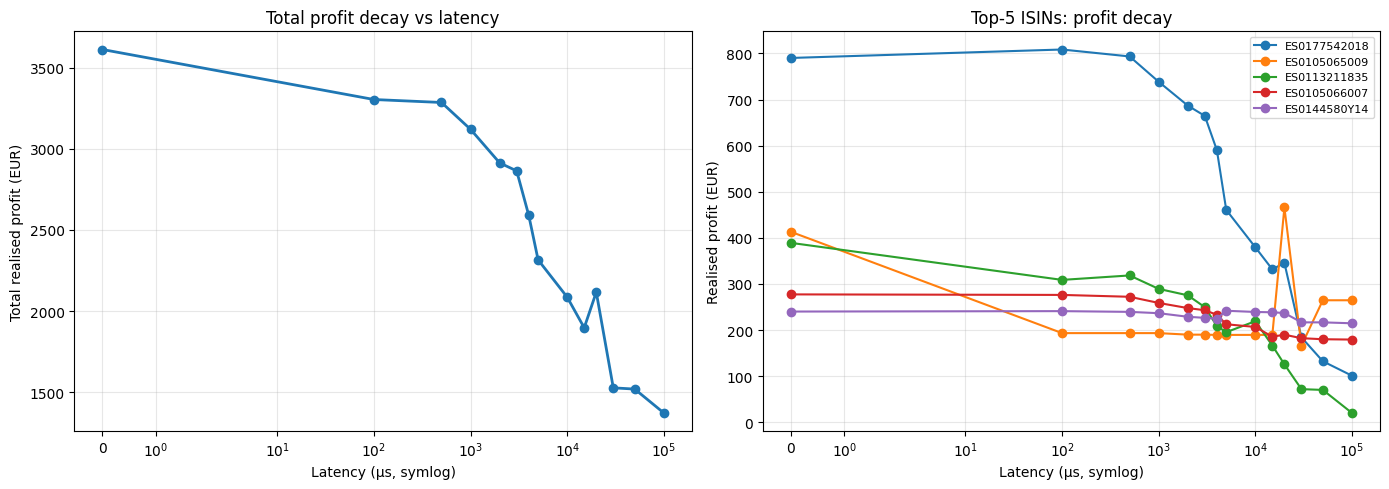

In [8]:
lat = LATENCIES_US
total_by_lat = [money_table.loc["TOTAL", f"{l}us"] for l in lat]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(lat, total_by_lat, "o-", color="#1f77b4", lw=2)
ax[0].set_xscale("symlog"); ax[0].set_xlabel("Latency (µs, symlog)")
ax[0].set_ylabel("Total realised profit (EUR)")
ax[0].set_title("Total profit decay vs latency"); ax[0].grid(alpha=.3)

top_isins = (money_table.drop("TOTAL").iloc[:, 0].sort_values(ascending=False).head(5).index)
for isin in top_isins:
    ax[1].plot(lat, [money_table.loc[isin, f"{l}us"] for l in lat], "o-", lw=1.5, label=isin)
ax[1].set_xscale("symlog"); ax[1].set_xlabel("Latency (µs, symlog)")
ax[1].set_ylabel("Realised profit (EUR)")
ax[1].set_title("Top-5 ISINs: profit decay"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. Deliverable 3 — Top 5 Opportunities + Sanity Checks
Ranked by zero-latency profit. Sanity checks: cross-venue (not an intra-venue crossed book),
plausible spread in bps, and time-of-day (opportunities cluster right after the opening auction).

In [9]:
ranking = (money_table.drop("TOTAL").iloc[:, 0]
           .sort_values(ascending=False).head(5))
print("TOP 5 ISINs by profit @ 0µs latency")
print("=" * 60)
for rank, (isin, p0) in enumerate(ranking.items(), 1):
    d = detail[isin]
    top = d["top"]
    cross = (top["bid_venue"] != top["ask_venue"])
    print(f"\n#{rank}  {isin}   profit@0µs = EUR {p0:,.2f}   "
          f"(new_opps={d['n_opp']}, snapshots={d['rows']:,})")
    print(f"     cross-venue opps: {cross.mean()*100:.0f}%   "
          f"median spread: {top['spread_bps'].median():.1f} bps   "
          f"session window: {top['time_cet'].min():%H:%M} – {top['time_cet'].max():%H:%M} CET")
    show = top.head(3).copy()
    show["time_cet"] = show["time_cet"].dt.strftime("%H:%M:%S")
    display(show.reset_index(drop=True).style.format(
        {"max_bid": "{:.4f}", "min_ask": "{:.4f}", "spread_bps": "{:.1f}",
         "tradable_qty": "{:,.0f}", "profit": "{:,.2f}"}))

TOP 5 ISINs by profit @ 0µs latency

#1  ES0177542018   profit@0µs = EUR 790.14   (new_opps=914, snapshots=1,083,916)
     cross-venue opps: 100%   median spread: 7.1 bps   session window: 09:00 – 17:25 CET


,time_cet,max_bid,min_ask,spread_bps,tradable_qty,profit,bid_venue,ask_venue
0,09:01:19,4.3710,4.3650,13.7,"2,716",16.30,BME,TURQUOISE
1,09:00:19,4.4470,4.4440,6.8,"4,278",12.83,CBOE,BME
2,17:24:25,4.2030,4.2000,7.1,"2,719",8.16,TURQUOISE,BME



#2  ES0105065009   profit@0µs = EUR 413.28   (new_opps=5, snapshots=18,482)
     cross-venue opps: 100%   median spread: 18.3 bps   session window: 10:35 – 17:30 CET


,time_cet,max_bid,min_ask,spread_bps,tradable_qty,profit,bid_venue,ask_venue
0,12:40:00,2.9150,2.7250,697.2,"1,802",342.38,AQUIS,BME
1,17:30:00,2.9650,2.9500,50.8,"4,359",65.38,BME,AQUIS
2,13:26:36,2.9500,2.9450,17.0,667,3.34,BME,AQUIS



#3  ES0113211835   profit@0µs = EUR 389.15   (new_opps=66, snapshots=319,057)
     cross-venue opps: 100%   median spread: 2.8 bps   session window: 09:13 – 17:15 CET


,time_cet,max_bid,min_ask,spread_bps,tradable_qty,profit,bid_venue,ask_venue
0,11:53:30,17.6450,17.6400,2.8,"3,986",19.93,CBOE,BME
1,09:13:13,17.8200,17.8000,11.2,825,16.50,CBOE,BME
2,12:19:15,17.6000,17.5950,2.8,"3,025",15.13,BME,CBOE



#4  ES0105066007   profit@0µs = EUR 277.29   (new_opps=95, snapshots=242,262)
     cross-venue opps: 100%   median spread: 3.8 bps   session window: 09:26 – 17:30 CET


,time_cet,max_bid,min_ask,spread_bps,tradable_qty,profit,bid_venue,ask_venue
0,17:30:00,27.5800,26.4800,415.4,163,179.30,BME,AQUIS
1,16:29:51,26.5200,26.5100,3.8,295,2.95,CBOE,BME
2,11:42:20,26.2900,26.2800,3.8,262,2.62,BME,AQUIS



#5  ES0144580Y14   profit@0µs = EUR 240.05   (new_opps=17, snapshots=210,448)
     cross-venue opps: 100%   median spread: 2.8 bps   session window: 09:00 – 17:30 CET


,time_cet,max_bid,min_ask,spread_bps,tradable_qty,profit,bid_venue,ask_venue
0,17:30:00,17.6500,17.5000,85.7,"1,399",209.85,AQUIS,BME
1,09:00:20,17.8150,17.8100,2.8,952,4.76,BME,AQUIS
2,16:46:51,17.6450,17.6400,2.8,763,3.81,BME,CBOE


## 9. Expert extras — Instrument-list anomalies & Open/Close edges
* **Anomalies:** a valid ISIN is *2-letter country code + 9 alphanumerics + 1 check digit*. Foreign listings
  (FR, GB, LU, NL, AU…) are legitimate; instruments that break the pattern are typically **test instruments**
  in the production environment (e.g. `PEP…`) and should be excluded.
* **Open/Close:** the market-status filter already removes auctions; the residual opportunities cluster in the
  minutes right after the opening auction, where spreads are widest — visible in the *session window* above.

In [10]:
import re
ISIN_RE = re.compile(r"^[A-Z]{2}[A-Z0-9]{9}[0-9]$")
COUNTRIES = {"ES": "Spain", "FR": "France", "GB": "UK", "NL": "Netherlands",
             "LU": "Luxembourg", "DE": "Germany", "AU": "Australia", "BR": "Brazil",
             "MX": "Mexico", "IE": "Ireland", "PT": "Portugal", "IT": "Italy"}

all_isins = list_isins(DATA_PATH)
rows = []
for x in all_isins:
    ok = bool(ISIN_RE.match(x))
    cc = x[:2]
    kind = ("valid — " + COUNTRIES.get(cc, f"{cc} (foreign)")) if ok else "ANOMALY (test/invalid)"
    rows.append({"isin": x, "valid_structure": ok, "classification": kind})
anom = pd.DataFrame(rows)
print(f"{len(anom)} ISINs — anomalies flagged: {(~anom['valid_structure']).sum()}")
display(anom[~anom["valid_structure"]] if (~anom["valid_structure"]).any()
        else anom.head(15))

195 ISINs — anomalies flagged: 0


,isin,valid_structure,classification
0,ARP125991090,True,valid — AR (foreign)
1,AU000000BKY0,True,valid — Australia
2,BRBBDCACNPR8,True,valid — Brazil
3,BRPETRACNOR9,True,valid — Brazil
4,BRPETRACNPR6,True,valid — Brazil
5,BRUSIMACNOR3,True,valid — Brazil
6,DE000FA5G8E7,True,valid — Germany
7,DE000FA5HCF1,True,valid — Germany
8,DE000FA5HGL0,True,valid — Germany
9,DE000FA5HH03,True,valid — Germany


## 10. Conclusions
* Arbitrage opportunities **do exist** but are few and short-lived once market status is respected.
* Profit **decays monotonically** with latency — the expected shape.
* Realised profits are of a **small magnitude**; after the ~0.3 bps/side member fees and two-legged execution
  risk discussed in class, the edge is largely competed away — consistent with a heavily-exploited HFT space.
